In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json

In [10]:
DATA_ROOT = "/workspace/yb-soc-two-body-loss/data/fig3b/param_search2"

In [11]:
def query_condition(name):
    return True

for name in os.listdir(DATA_ROOT):
    if query_condition(name):
        print(name)

fig3mixture_nh_13_6_09061631
fig3mixture_nh_13_6_09061707
fig3mixture_nh_13_6_09061744
fig3mixture_nh_13_6_09061820
fig3mixture_nh_13_6_09061856


In [12]:
DATA_SUBDIR_LIST = [
    "fig3superposition_nh_13_2_09081929",
    "fig3superposition_nh_13_3_09081929",
    "fig3superposition_nh_13_4_09081929",
    "fig3superposition_nh_13_5_09081931",
    # "fig3superposition_nh_13_6_09081948",
]
DATA_SUBDIR_FULL = [
    os.path.join(DATA_ROOT, name) for name in DATA_SUBDIR_LIST
]

In [13]:
def load_params(data_dir):
    data_path = os.path.join(data_dir, "data/parameters.json")
    with open(data_path, 'r') as f:
        params = json.load(f)
    return params

def load_nparray(data_dir, file_name):
    data_path = os.path.join(data_dir, "data", file_name)
    with open(data_path, 'rb') as f:
        nparr = np.load(f)
    return nparr

def load_times(data_dir):
    return load_nparray(data_dir, "t.npy")

def load_full_momentum_nums(data_dir):
    up_nums = load_nparray(data_dir, "full_up_nums_momentum.npy")
    down_nums = load_nparray(data_dir, "full_down_nums_momentum.npy")
    return up_nums, down_nums

def load_nh_state_norm_square(data_dir):
    state_norm_sq = load_nparray(data_dir, "state_norm_square_nh.npy")
    return state_norm_sq

In [14]:
err = 0
params = []
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    params.append(load_params(data_dir))

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/yb-soc-two-body-loss/data/fig3b/param_search2/fig3superposition_nh_13_2_09081929/data/parameters.json'

In [15]:
def merge_params(params_list):
    if not params_list:
        return {}, []

    merged_keys = set()

    def _recursive_merge(current_params_list, path_prefix=""):
        if not current_params_list:
            return {}

        all_keys = set().union(*(d.keys() for d in current_params_list))
        merged_dict = {}

        for key in all_keys:
            values = [d.get(key) for d in current_params_list if key in d]
            
            unique_values = []
            for v in values:
                if v not in unique_values:
                    unique_values.append(v)
            
            full_key_path = f"{path_prefix}{key}"

            if len(unique_values) == 1:
                merged_dict[key] = unique_values[0]
            else:
                if all(isinstance(v, dict) for v in unique_values):
                    merged_dict[key] = _recursive_merge(unique_values, path_prefix=f"{full_key_path}.")
                else:
                    merged_keys.add(full_key_path)
                    merged_dict[key] = unique_values
        
        return merged_dict

    final_merged_dict = _recursive_merge(params_list)

    return final_merged_dict, sorted(list(merged_keys))

In [16]:
merged_params, merged = merge_params(params)
# print(merged)
# pointer = merged_params
# for key in merged[0].split('.'):
#     pointer = pointer[key]
# print(f"{key}: {pointer}")
print(json.dumps(merged_params, indent=4))

{}


In [17]:
err = 0
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    ts = load_times(data_dir)
    if idx == 0:
        ts_ref = ts
    else:
        err += np.mean(np.abs(ts - ts_ref))
print('error:', err)

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/yb-soc-two-body-loss/data/fig3b/param_search2/fig3superposition_nh_13_2_09081929/data/t.npy'

In [22]:
# System definition
t_r = 0.1129 # ms
E_r = 9.3428e-31 # J
T_r = 6.7669e-2 # μK

In [18]:
exp_data_path = "/workspace/yb-soc-two-body-loss/data/experiment/OneDrive_1_7-5-2025/unit_figure_3_b.csv"

In [19]:
import pandas as pd
df_fig3a = pd.read_csv(exp_data_path)
time_exp = np.array(df_fig3a["time"]) * 1000 # s -> ms
nums_exp = np.array(df_fig3a["mean"])
errors_exp = np.array(df_fig3a["se"])

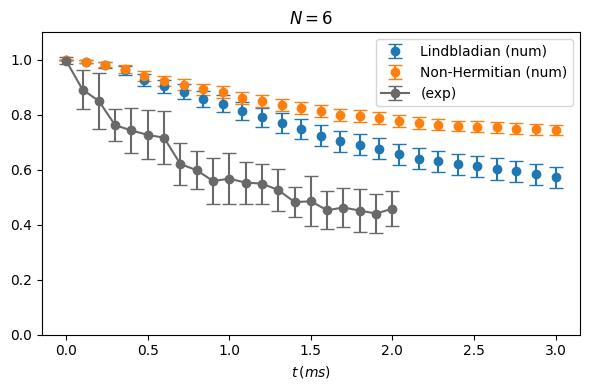

In [ ]:
for data_dir in [1]:
    data_dir = "/workspace/yb-soc-two-body-loss/data/fig3b/param_search2/fig3mixture_nh_13_6_09061820"
    params = load_params(data_dir)
    save_at = load_times(data_dir)
    ts = save_at * t_r
    n_particles = params['n_particles']
    nums_up, nums_down = load_full_momentum_nums(data_dir)
    norm_sq_nh = load_nh_state_norm_square(data_dir)
    assert nums_up.shape == nums_down.shape
    n_traj = nums_up.shape[0]
    
    nums_up /= n_particles
    nums_down /= n_particles
    
    total_nums = np.sum(nums_up, axis=2) + np.sum(nums_down, axis=2)
    nums = np.mean(total_nums, axis=0)
    stds = np.std(total_nums, axis=0)
    errors = 3 * stds / np.sqrt(n_traj)
    
    temp = (2 * norm_sq_nh + (n_particles - 2)) / n_particles
    nums_nh = np.mean(temp, axis=0)
    stds_nh = np.std(temp, axis=0)
    errors_nh = 3 * stds_nh / np.sqrt(n_traj)
    
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.set_title(f"$N = {n_particles}$")
    ax.errorbar(ts[::3], nums[::3], yerr=errors[::3], fmt='o', capsize=5, color='tab:blue', label='Lindbladian (num)')
    ax.errorbar(ts[::3], nums_nh[::3], yerr=errors_nh[::3], fmt='o', capsize=5, color='tab:orange', label='Non-Hermitian (num)')
    ax.errorbar(time_exp, nums_exp, yerr=errors_exp, fmt='o-', capsize=5, color='dimgrey', label='(exp)')
    ax.legend()
    ax.set_ylim(0.0, 1.1)
    ax.set_xlabel("$t\\,(ms)$")

    plt.tight_layout()
    plt.show()
    break
    

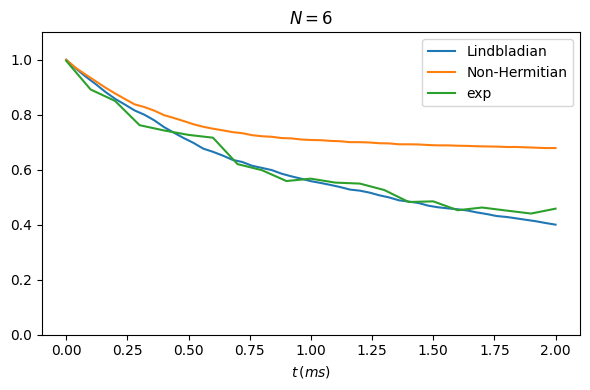

In [ ]:
data_dir = DATA_SUBDIR_FULL[0]
params = load_params(data_dir)
n = params['n_particles']
state_norm_square_nh = load_nh_state_norm_square(data_dir)
total_nums_nh = 2 * np.mean(state_norm_square_nh, axis=0) + (n - 2)

nums_up, nums_down = load_full_momentum_nums(data_dir)
nums_up_avg = np.mean(nums_up, axis=0)
nums_down_avg = np.mean(nums_down, axis=0)
total_nums_lindblad = np.sum(nums_up_avg, axis=-1) + np.sum(nums_down_avg, axis=-1)

save_at = load_times(data_dir)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ts = save_at * t_r
ax.set_title(f"$N={n}$")
ax.plot(ts, total_nums_lindblad / n, label='Lindbladian')
ax.plot(ts, total_nums_nh / n, label='Non-Hermitian')
ax.plot(exp_time, exp_nums, label='exp')
ax.legend()
ax.set_ylim(0.0, 1.1)
ax.set_xlabel("$t\\,(ms)$")

plt.tight_layout()
plt.show()

In [ ]:
ts = ts_ref
ts_ms = ts_ref * t_r
print(f"{len(ts)=}")
print(ts_ms)

len(ts)=51
[0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.  ]


In [ ]:
n_particles = merged_params['n_particles']

In [ ]:
n_particles

[2, 3, 4, 5, 6]

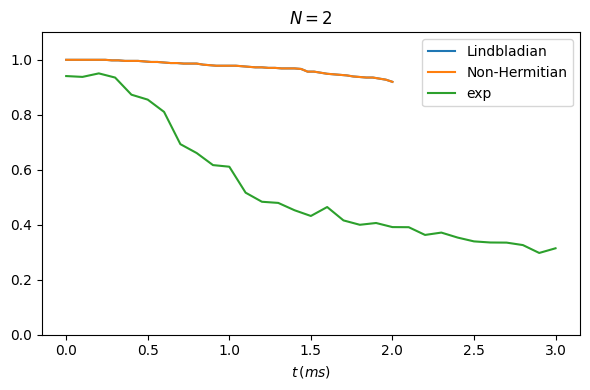

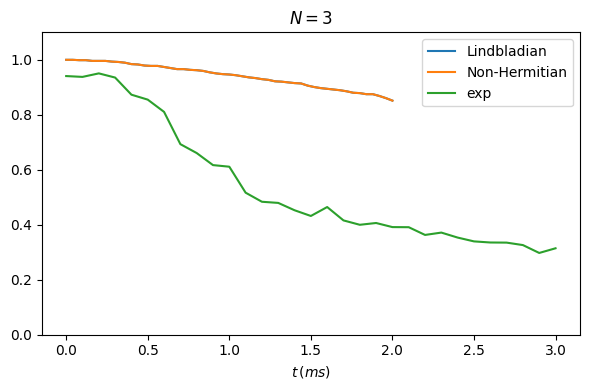

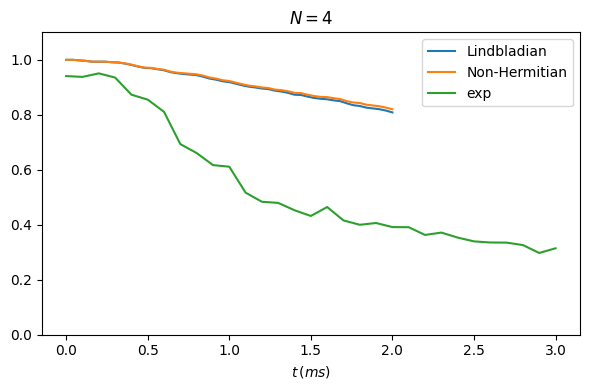

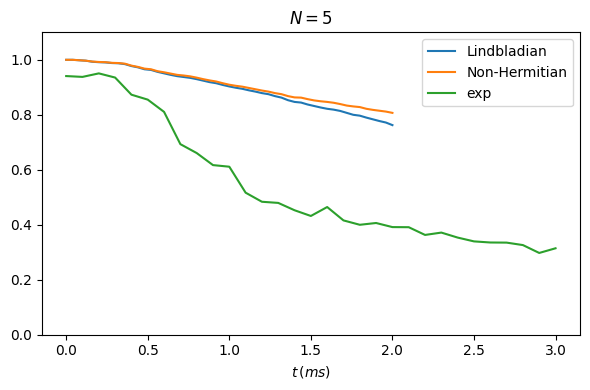

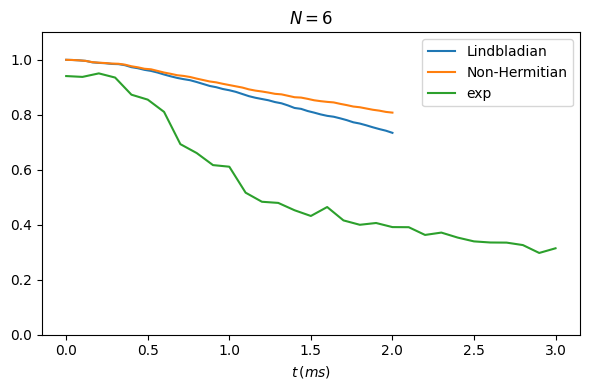

In [ ]:
from quant_mech.plot_utils import (
    plot_numbers,
    generate_k_labels,
    plot_fractions
)

for n, data_dir in zip(n_particles, DATA_SUBDIR_FULL):
    # (batch, time, k)
    params = load_params(data_dir)
    state_norm_square_nh = load_nh_state_norm_square(data_dir)
    total_nums_nh = 2 * np.mean(state_norm_square_nh, axis=0) + (n - 2)
    
    nums_up, nums_down = load_full_momentum_nums(data_dir)
    nums_up_avg = np.mean(nums_up, axis=0)
    nums_down_avg = np.mean(nums_down, axis=0)
    total_nums_lindblad = np.sum(nums_up_avg, axis=-1) + np.sum(nums_down_avg, axis=-1)
    
    save_at = load_times(data_dir)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ts = save_at * t_r
    ax.set_title(f"$N={n}$")
    ax.plot(ts, total_nums_lindblad / n, label='Lindbladian')
    ax.plot(ts, total_nums_nh / n, label='Non-Hermitian')
    ax.plot(exp_time, exp_nums, label='exp')
    ax.legend()
    ax.set_ylim(0.0, 1.1)
    ax.set_xlabel("$t\\,(ms)$")

    plt.tight_layout()
    plt.show()